In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = sns.load_dataset('tips')

# Let's "simulate" some messy data (Missing values)
# so you can demonstrate cleaning skills
import numpy as np
df.loc[0:10, 'time'] = np.nan

print("Data Loaded. Missing values found:")
print(df.isnull().sum())

Data Loaded. Missing values found:
total_bill     0
tip            0
sex            0
smoker         0
day            0
time          11
size           0
dtype: int64


In [2]:
# 1. Fill missing values in 'time' with the most common value (Mode)
df['time'] = df['time'].fillna(df['time'].mode()[0])

# 2. Check for duplicates and drop them
df = df.drop_duplicates()

print("Cleaning Complete. New missing value count:")
print(df.isnull().sum())

Cleaning Complete. New missing value count:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [3]:
# Convert the 'time' column into numbers
# Lunch will become 0, Dinner will become 1
df['time_code'] = df['time'].astype('category').cat.codes

print("Label Encoding Sample:")
print(df[['time', 'time_code']].head(15))

Label Encoding Sample:
      time  time_code
0   Dinner          1
1   Dinner          1
2   Dinner          1
3   Dinner          1
4   Dinner          1
5   Dinner          1
6   Dinner          1
7   Dinner          1
8   Dinner          1
9   Dinner          1
10  Dinner          1
11  Dinner          1
12  Dinner          1
13  Dinner          1
14  Dinner          1


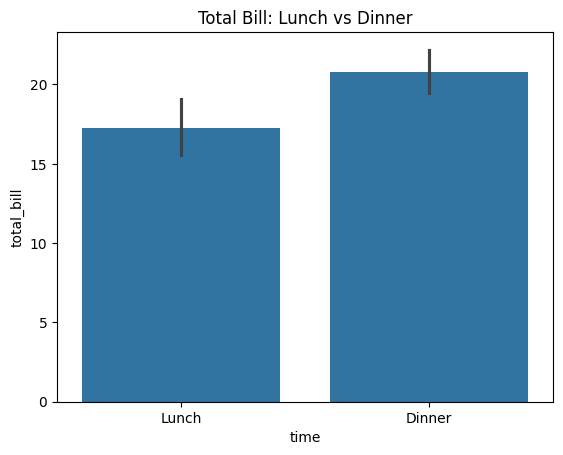

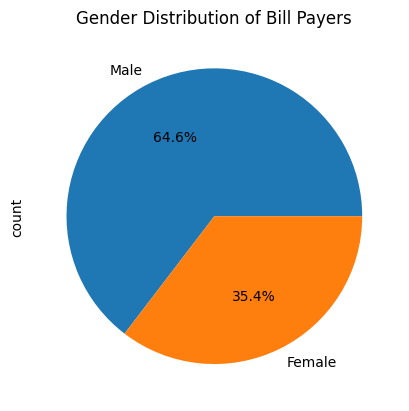

In [4]:
# Insight 1: Total Bill by Time
sns.barplot(x='time', y='total_bill', data=df)
plt.title('Total Bill: Lunch vs Dinner')
plt.show()

# Insight 2: Count of Gender
df['sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender Distribution of Bill Payers')
plt.show()

/tmp/ipython-input-266/745490073.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day', data=df, palette='viridis')


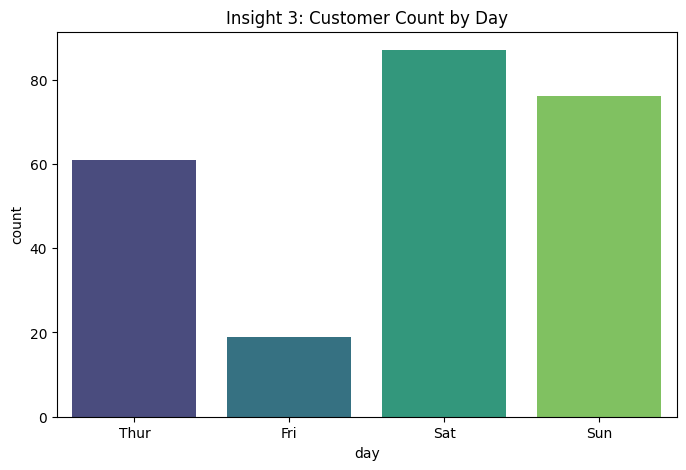

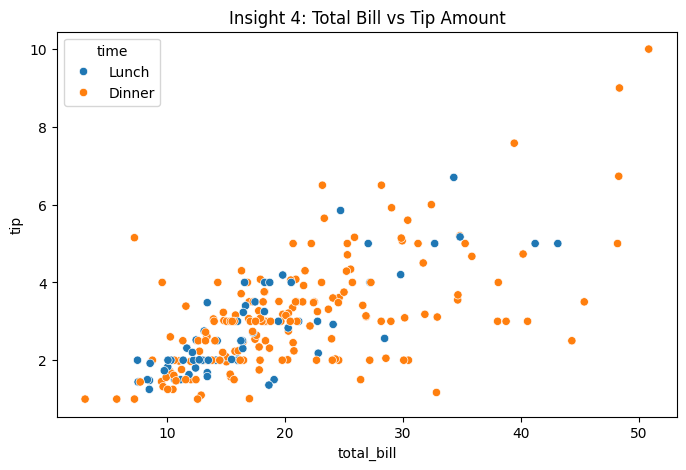

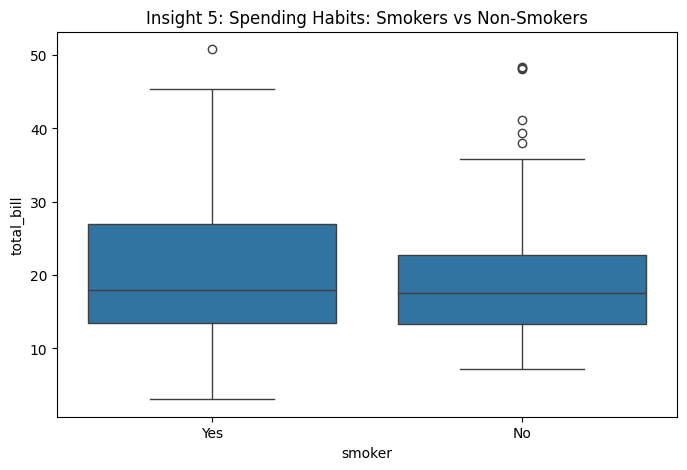

In [5]:
# Insight 3: Busy Days - Which day has the most customers?
plt.figure(figsize=(8,5))
sns.countplot(x='day', data=df, palette='viridis')
plt.title('Insight 3: Customer Count by Day')
plt.show()

# Insight 4: Correlation - Does a bigger bill lead to a bigger tip?
plt.figure(figsize=(8,5))
sns.scatterplot(x='total_bill', y='tip', data=df, hue='time')
plt.title('Insight 4: Total Bill vs Tip Amount')
plt.show()

# Insight 5: Smoker Behavior - Do smokers spend more on average?
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='total_bill', data=df)
plt.title('Insight 5: Spending Habits: Smokers vs Non-Smokers')
plt.show()